# E3.0 — Preliminary RDF Analysis (Existing 10 ns Trajectories)

Computes atom-pair radial distribution functions between DES component atoms and motif backbone oxygen atoms for all 9 systems. Identifies first RDF minima for pair-specific coordination cutoffs.

**Objective:** Determine whether the uniform 0.35 nm cutoff used in Phase 3 is appropriate for all atom pairs, or whether pair-specific cutoffs (particularly for bulkier DES components) would change coordination numbers.

**Author:** Ross Gibson  
**Date:** June 2026

In [1]:
import os
import numpy as np
import mdtraj as md
import matplotlib.pyplot as plt
from itertools import product as iterproduct
import csv
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

print("Imports complete")

Imports complete


## Configuration

System definitions, motif residue indices, and DES component atom selections.

**Motif residue indices in topology** (0-indexed, ACE cap = residue 0):
- GGE construct: ACE-E-E-E-**G-G-E**-I-V-F-NME → motif at residues 4, 5, 6
- CME construct: ACE-L-Y-Q-**C-M-E**-F-V-R-NME → motif at residues 4, 5, 6
- YIY construct: ACE-N-P-**Y-I-Y**-K-NME → motif at residues 3, 4, 5

In [2]:
BASE_DIR = os.path.expanduser("~/des-peptide-study")
os.chdir(BASE_DIR)

SYSTEMS = {
    "GGE_water":     ("systems/GGE_water/GGE_water.prmtop",
                      "systems/GGE_water/GGE_water_prod.dcd"),
    "GGE_reline":    ("systems/GGE_reline/GGE_reline.prmtop",
                      "systems/GGE_reline/GGE_reline_prod.dcd"),
    "GGE_glyceline": ("systems/GGE_glyceline/GGE_glyceline.prmtop",
                      "systems/GGE_glyceline/GGE_glyceline_prod.dcd"),
    "CME_water":     ("systems/CME_water/CME_water.prmtop",
                      "systems/CME_water/CME_water_prod.dcd"),
    "CME_reline":    ("systems/CME_reline/CME_reline.prmtop",
                      "systems/CME_reline/CME_reline_prod.dcd"),
    "CME_glyceline": ("systems/CME_glyceline/CME_glyceline.prmtop",
                      "systems/CME_glyceline/CME_glyceline_prod.dcd"),
    "YIY_water":     ("systems/YIY_water/YIY_water.prmtop",
                      "systems/YIY_water/YIY_water_prod.dcd"),
    "YIY_reline":    ("systems/YIY_reline/YIY_reline.prmtop",
                      "systems/YIY_reline/YIY_reline_prod.dcd"),
    "YIY_glyceline": ("systems/YIY_glyceline/YIY_glyceline.prmtop",
                      "systems/YIY_glyceline/YIY_glyceline_prod.dcd"),
}

MOTIF_RESIDUES = {
    "GGE": [4, 5, 6],
    "CME": [4, 5, 6],
    "YIY": [3, 4, 5],
}

PARTNER_SELECTIONS = {
    "water": [("HOH", ["O"], "Water O")],
    "reline": [
        ("HOH", ["O"],       "Water O"),
        ("CHO", ["N"],       "Choline N"),
        ("CLA", ["Cl"],      "Chloride"),
        ("URE", ["N", "N1"], "Urea N"),
        ("URE", ["O"],       "Urea O"),
    ],
    "glyceline": [
        ("HOH", ["O"],             "Water O"),
        ("CHO", ["N"],             "Choline N"),
        ("CLA", ["Cl"],            "Chloride"),
        ("GOL", ["O", "O1", "O2"], "Glycerol O"),
    ],
}

RDF_BIN_WIDTH = 0.005   # nm
RDF_RANGE = (0.15, 1.0) # nm
EQ_CUTOFF_NS = 1.0      # ns
SAVE_INTERVAL_PS = 1.0   # ps per frame
DEFAULT_CUTOFF = 0.35    # nm

print(f"Systems: {len(SYSTEMS)}")
print(f"RDF range: {RDF_RANGE[0]}–{RDF_RANGE[1]} nm, bin width: {RDF_BIN_WIDTH} nm")

Systems: 9
RDF range: 0.15–1.0 nm, bin width: 0.005 nm


## Helper Functions

Atom selection, pair generation, and RDF first-minimum detection.

In [3]:
def get_motif_backbone_O(topology, motif_residue_indices):
    """Get atom indices for backbone carbonyl O atoms in motif residues."""
    indices = []
    for res_idx in motif_residue_indices:
        res = topology.residue(res_idx)
        for atom in res.atoms:
            if atom.name == "O" and atom.element.symbol == "O":
                indices.append(atom.index)
                break
    return np.array(indices)


def get_partner_atoms(topology, residue_name, atom_names):
    """Get atom indices for specified atoms in all residues of a given name."""
    indices = []
    for res in topology.residues:
        if res.name == residue_name:
            for atom in res.atoms:
                if atom.name in atom_names:
                    indices.append(atom.index)
    return np.array(indices)


def make_pairs(group_a, group_b):
    """Generate all (i, j) pairs between two atom index arrays."""
    return np.array(list(iterproduct(group_a, group_b)))


def find_first_minimum(r, g_r, search_start=0.2, search_end=0.6):
    """
    Find the first minimum in g(r) after the first peak.
    Applies light smoothing to avoid noise-induced false minima.
    """
    mask = (r >= search_start) & (r <= search_end)
    r_sub = r[mask]
    g_sub = g_r[mask]
    
    if len(g_sub) < 5:
        return np.nan, np.nan
    
    kernel_size = max(3, int(0.01 / RDF_BIN_WIDTH))
    if kernel_size % 2 == 0:
        kernel_size += 1
    kernel = np.ones(kernel_size) / kernel_size
    g_smooth = np.convolve(g_sub, kernel, mode='same')
    
    peak_idx = None
    for i in range(1, len(g_smooth) - 1):
        if g_smooth[i] > g_smooth[i-1] and g_smooth[i] > g_smooth[i+1] and g_smooth[i] > 1.0:
            peak_idx = i
            break
    
    if peak_idx is None:
        return np.nan, np.nan
    
    for i in range(peak_idx + 1, len(g_smooth) - 1):
        if g_smooth[i] < g_smooth[i-1] and g_smooth[i] < g_smooth[i+1]:
            return r_sub[i], g_smooth[i]
    
    return np.nan, np.nan


def get_solvent_type(system_name):
    if "reline" in system_name:
        return "reline"
    elif "glyceline" in system_name:
        return "glyceline"
    return "water"


def get_peptide_name(system_name):
    return system_name.split("_")[0]


print("Helper functions defined")

Helper functions defined


## RDF Computation

Load each trajectory, compute RDFs for all relevant atom pairs, and identify first minima. This is the main analysis loop — expect ~2–5 minutes for all 9 systems.

In [4]:
all_results = []
all_rdfs = {}

out_dir = os.path.join(BASE_DIR, "extension", "analysis", "preliminary_rdfs")
os.makedirs(out_dir, exist_ok=True)

for sys_name, (prmtop_path, dcd_path) in SYSTEMS.items():
    peptide = get_peptide_name(sys_name)
    solvent = get_solvent_type(sys_name)
    
    print(f"\n{'─'*60}")
    print(f"Loading {sys_name}...")
    
    traj = md.load(dcd_path, top=prmtop_path)
    eq_frames = int(EQ_CUTOFF_NS * 1000 / SAVE_INTERVAL_PS)
    traj = traj[eq_frames:]
    print(f"  Frames after {EQ_CUTOFF_NS} ns cutoff: {traj.n_frames}")
    
    motif_res = MOTIF_RESIDUES[peptide]
    backbone_O = get_motif_backbone_O(traj.topology, motif_res)
    print(f"  Motif backbone O atoms: {len(backbone_O)} (residues {motif_res})")
    
    partners = PARTNER_SELECTIONS[solvent]
    
    for res_name, atom_names, label in partners:
        partner_idx = get_partner_atoms(traj.topology, res_name, atom_names)
        
        if len(partner_idx) == 0:
            print(f"  {label}: no atoms found — skipping")
            continue
        
        pairs = make_pairs(backbone_O, partner_idx)
        print(f"  {label}: {len(partner_idx)} atoms, {len(pairs)} pairs ... ", end="", flush=True)
        
        n_bins = int((RDF_RANGE[1] - RDF_RANGE[0]) / RDF_BIN_WIDTH)
        r, g_r = md.compute_rdf(
            traj,
            pairs=pairs,
            r_range=RDF_RANGE,
            n_bins=n_bins,
            periodic=True,
        )
        
        r_min, g_min = find_first_minimum(r, g_r)
        
        delta = (r_min - DEFAULT_CUTOFF) * 10 if not np.isnan(r_min) else np.nan
        
        status = f"first min = {r_min:.3f} nm (g = {g_min:.2f})" if not np.isnan(r_min) else "no clear minimum found"
        print(status)
        
        all_rdfs[(sys_name, label)] = (r, g_r)
        all_results.append({
            "system": sys_name,
            "peptide": peptide,
            "solvent": solvent,
            "partner": label,
            "n_partner_atoms": len(partner_idx),
            "n_pairs": len(pairs),
            "first_min_nm": r_min,
            "first_min_g": g_min,
            "default_cutoff_nm": DEFAULT_CUTOFF,
            "delta_from_default_A": delta,
        })

print(f"\n{'='*60}")
print(f"RDF computation complete: {len(all_results)} pair analyses across {len(SYSTEMS)} systems")


────────────────────────────────────────────────────────────
Loading GGE_water...
  Frames after 1.0 ns cutoff: 9000
  Motif backbone O atoms: 3 (residues [4, 5, 6])
  Water O: 899 atoms, 2697 pairs ... first min = 0.333 nm (g = 0.38)

────────────────────────────────────────────────────────────
Loading GGE_reline...
  Frames after 1.0 ns cutoff: 9000
  Motif backbone O atoms: 3 (residues [4, 5, 6])
  Water O: 744 atoms, 2232 pairs ... first min = 0.333 nm (g = 0.37)
  Choline N: 13 atoms, 39 pairs ... first min = 0.387 nm (g = 3.09)
  Chloride: 13 atoms, 39 pairs ... no clear minimum found
  Urea N: 52 atoms, 156 pairs ... first min = 0.358 nm (g = 0.68)
  Urea O: 26 atoms, 78 pairs ... first min = 0.538 nm (g = 0.84)

────────────────────────────────────────────────────────────
Loading GGE_glyceline...
  Frames after 1.0 ns cutoff: 9000
  Motif backbone O atoms: 3 (residues [4, 5, 6])
  Water O: 751 atoms, 2253 pairs ... first min = 0.333 nm (g = 0.33)
  Choline N: 10 atoms, 30 pair

## Summary Table

First RDF minima compared with the Phase 3 default cutoff of 0.35 nm. Pairs flagged where the first minimum differs by > 0.5 Å.

In [5]:
print(f"{'System':<20} {'Partner':<15} {'1st min (nm)':>12} {'g(r_min)':>10} {'Δ from 0.35':>12}")
print(f"{'─'*70}")

for res in all_results:
    r_min = res["first_min_nm"]
    g_min = res["first_min_g"]
    delta = res["delta_from_default_A"]
    
    r_str = f"{r_min:.3f}" if not np.isnan(r_min) else "N/A"
    g_str = f"{g_min:.2f}" if not np.isnan(g_min) else "N/A"
    d_str = f"{delta:+.2f} Å" if not np.isnan(delta) else "N/A"
    
    print(f"{res['system']:<20} {res['partner']:<15} {r_str:>12} {g_str:>10} {d_str:>12}")

print(f"\n{'─'*70}")
print("Pairs where first minimum differs from 0.35 nm by > 0.5 Å:")
flagged = [r for r in all_results if not np.isnan(r["delta_from_default_A"]) 
           and abs(r["delta_from_default_A"]) > 0.5]
if flagged:
    for r in flagged:
        print(f"  {r['system']:20s} {r['partner']:15s} → {r['first_min_nm']:.3f} nm "
              f"(Δ = {r['delta_from_default_A']:+.2f} Å)")
else:
    print("  None — 0.35 nm appears adequate for all pairs at 10 ns resolution")

System               Partner         1st min (nm)   g(r_min)  Δ from 0.35
──────────────────────────────────────────────────────────────────────
GGE_water            Water O                0.333       0.38      -0.17 Å
GGE_reline           Water O                0.333       0.37      -0.17 Å
GGE_reline           Choline N              0.387       3.09      +0.37 Å
GGE_reline           Chloride                 N/A        N/A          N/A
GGE_reline           Urea N                 0.358       0.68      +0.08 Å
GGE_reline           Urea O                 0.538       0.84      +1.88 Å
GGE_glyceline        Water O                0.333       0.33      -0.17 Å
GGE_glyceline        Choline N              0.403       2.98      +0.53 Å
GGE_glyceline        Chloride                 N/A        N/A          N/A
GGE_glyceline        Glycerol O               N/A        N/A          N/A
CME_water            Water O                0.333       0.28      -0.17 Å
CME_reline           Water O             

## RDF Plots

3×3 grid: peptides (rows) × solvents (columns). Each panel shows all computed RDFs with first minima marked (▼) and the 0.35 nm default cutoff as a dotted reference line.

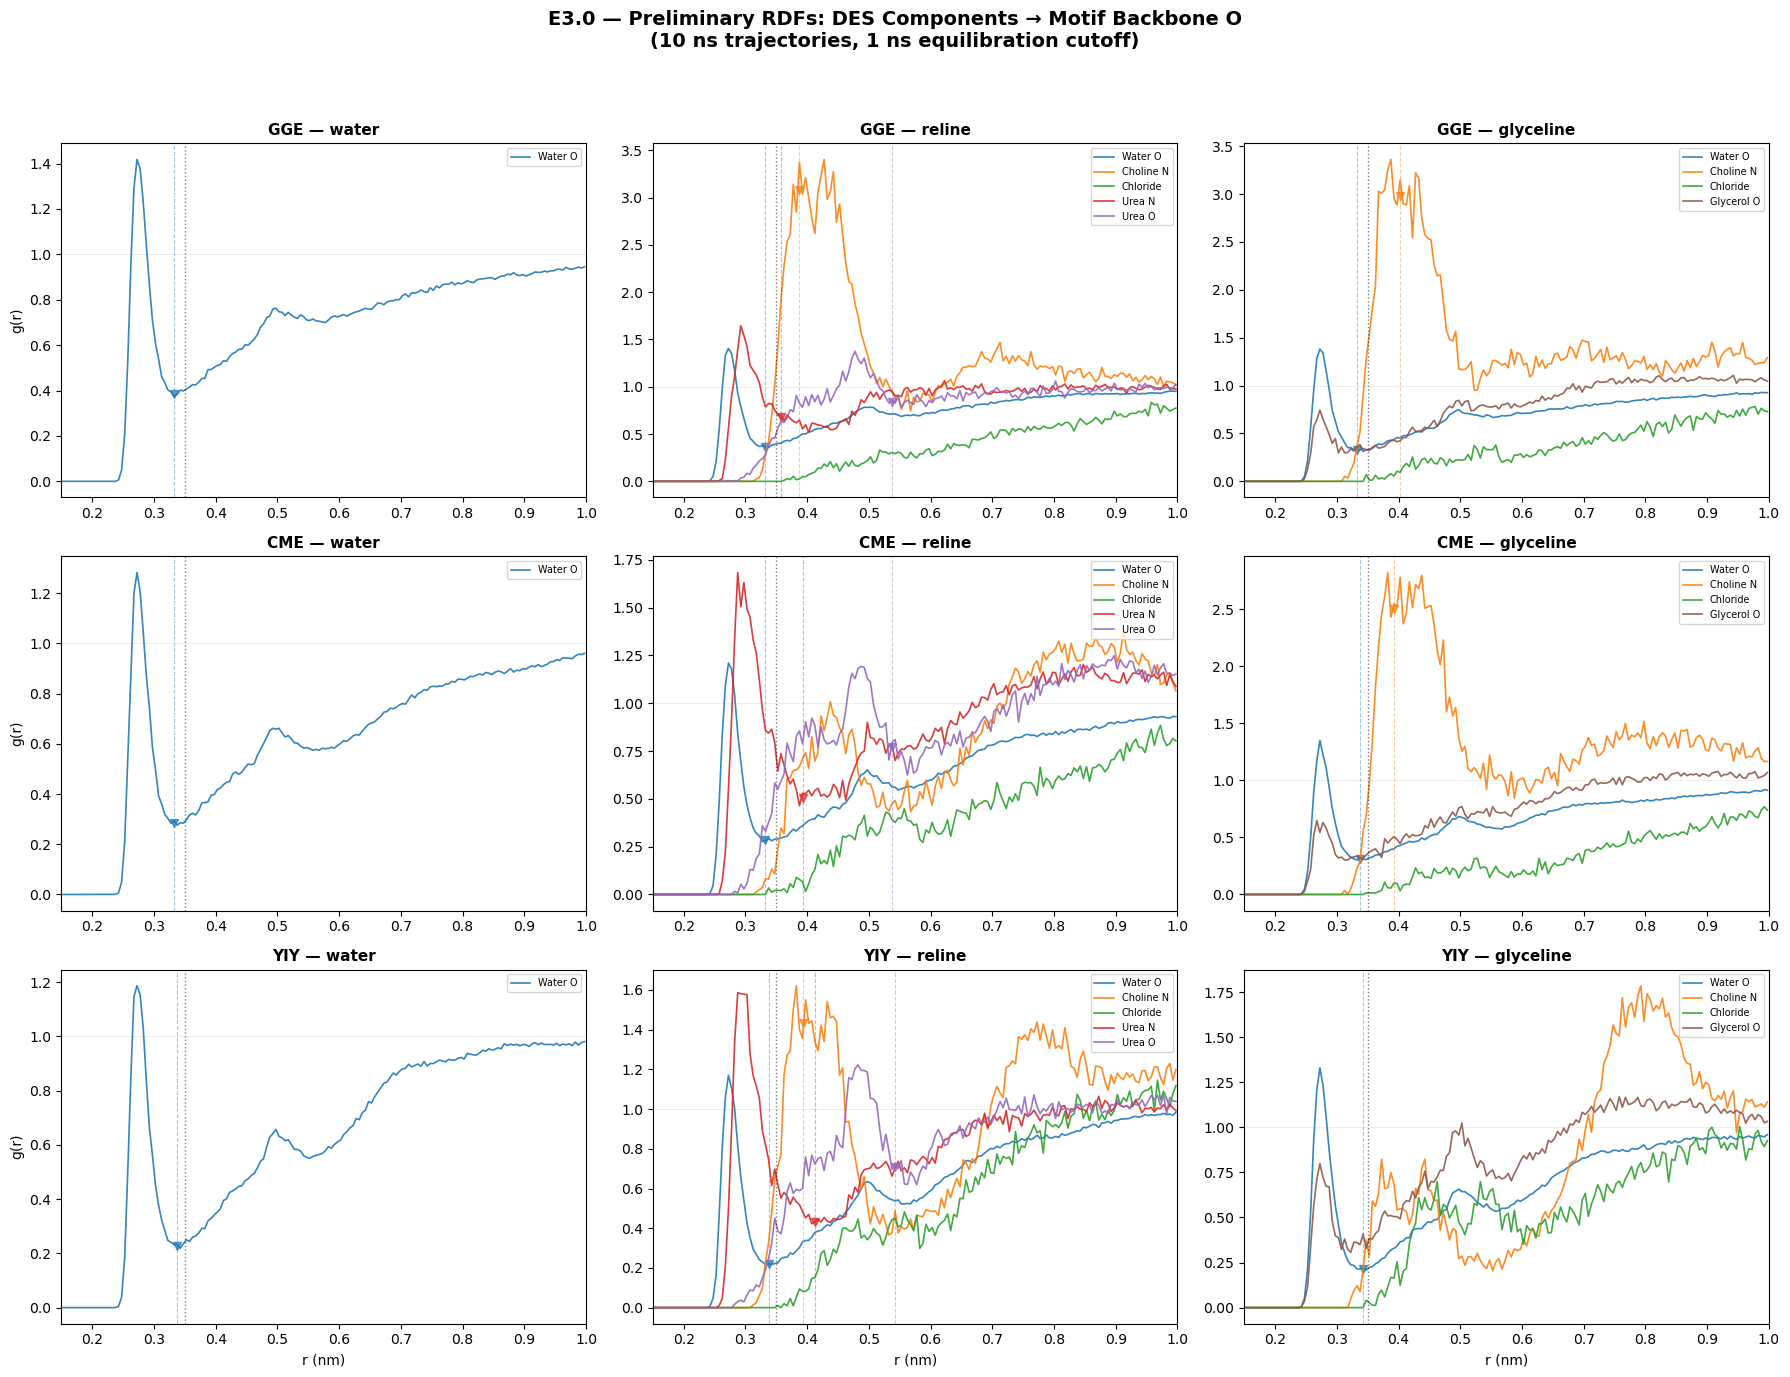

Figure saved: /Users/rossgibson/des-peptide-study/extension/analysis/preliminary_rdfs/preliminary_rdfs_all_systems.png


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("E3.0 — Preliminary RDFs: DES Components → Motif Backbone O\n"
             "(10 ns trajectories, 1 ns equilibration cutoff)", fontsize=14, fontweight="bold")

peptide_names = ["GGE", "CME", "YIY"]
solvent_names = ["water", "reline", "glyceline"]
solvent_colors = {
    "Water O":     "#1f77b4",
    "Choline N":   "#ff7f0e",
    "Chloride":    "#2ca02c",
    "Urea N":      "#d62728",
    "Urea O":      "#9467bd",
    "Glycerol O":  "#8c564b",
}

for row, peptide in enumerate(peptide_names):
    for col, solvent in enumerate(solvent_names):
        ax = axes[row, col]
        sys_name = f"{peptide}_{solvent}"
        
        partners = PARTNER_SELECTIONS[solvent]
        has_data = False
        
        for _, _, label in partners:
            key = (sys_name, label)
            if key in all_rdfs:
                r, g_r = all_rdfs[key]
                color = solvent_colors.get(label, "gray")
                ax.plot(r, g_r, color=color, linewidth=1.2, label=label, alpha=0.9)
                
                result = [res for res in all_results 
                         if res["system"] == sys_name and res["partner"] == label]
                if result and not np.isnan(result[0]["first_min_nm"]):
                    r_min = result[0]["first_min_nm"]
                    g_min = result[0]["first_min_g"]
                    ax.axvline(r_min, color=color, linestyle="--", alpha=0.4, linewidth=0.8)
                    ax.plot(r_min, g_min, "v", color=color, markersize=6, alpha=0.7)
                
                has_data = True
        
        ax.axvline(DEFAULT_CUTOFF, color="black", linestyle=":", alpha=0.5, linewidth=1.0)
        ax.axhline(1.0, color="gray", linestyle="-", alpha=0.2, linewidth=0.5)
        ax.set_xlim(RDF_RANGE)
        ax.set_title(f"{peptide} — {solvent}", fontsize=11, fontweight="bold")
        
        if row == 2:
            ax.set_xlabel("r (nm)")
        if col == 0:
            ax.set_ylabel("g(r)")
        
        if has_data:
            ax.legend(fontsize=7, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig_path = os.path.join(out_dir, "preliminary_rdfs_all_systems.png")
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

## Save Results

In [7]:
csv_path = os.path.join(out_dir, "preliminary_rdf_cutoffs.csv")
fieldnames = ["system", "peptide", "solvent", "partner", "n_partner_atoms", "n_pairs",
              "first_min_nm", "first_min_g", "default_cutoff_nm", "delta_from_default_A"]
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(all_results)

print(f"Results saved: {csv_path}")
print(f"\nE3.0 COMPLETE")

Results saved: /Users/rossgibson/des-peptide-study/extension/analysis/preliminary_rdfs/preliminary_rdf_cutoffs.csv

E3.0 COMPLETE
